## Curating the data

This notebook extracts the optimised grating data from the formatted .pkl files produced by the optimisation script.

### Sort the maxima found from each core

In [1]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


#final_speed = 20.
num_cores = 200
maxtime = 1440
runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
runID = "Fasymp4_fixgaussian20_50GW" # _nG30"

student = "Shaurya/Grating_Entire"  # Change this to your name or preferred folder name

# common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
# custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}"

filepath = "Z:\\Github\\relativistic-lightsail-dynamics\\Optimisation\\run_parallel_extract.ipynb"
filepath = "run_parallel_extract.ipynb"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 663204
Average function evaluations per core: 3316


### Write the sorted maxima to file

In [2]:
lines_to_file = ["\n------------------------------------------------------------------------------------------------------------------------------------\n"
                , f"All maxima | (local maximum, local maximiser)\n"]

with open(txt_fname, "a") as result_file:
    result_file.writelines(lines_to_file)
    
    for idx, maxima_and_maximiser in enumerate(maxima_and_maximisers_sorted):
        result_file.write(f"Max no. {idx} | {maxima_and_maximiser}\n")

    result_file.write("------------------------------------------------------------------------------------------------------------------------------------\n")

In [3]:
import parameters

### Write sorted maxima to file using secondary FOM

In [4]:
final_speed = parameters.final_speed
final_speed

np.float64(4.875148629914703)

In [5]:
choose_monofom = fom.monofom_max_eigval
maxima = []
maxima2 = []
for (opt_FOM, opt_grating) in opt_gratings_sorted:
    opt_grating.npa = autolib.AutoLib(lib="torch", device="cpu", precision="double")
    FOM = fom.multifom(opt_grating, monofom=choose_monofom, final_speed=final_speed, goal=0.1, return_grad=False)
    maxima2.append((opt_FOM, FOM))

lines_to_file = ["\n------------------------------------------------------------------------------------------------------------------------------------\n"
                , f"All maxima | (Original FOM, Second FOM)\n"]

with open(str(fname_preamble/txt_fname.stem)+"_secondFOM.txt", "a") as result_file:
    result_file.writelines(lines_to_file)
    
    for idx, maxima in enumerate(maxima2):
        result_file.write(f"Max no. {idx} | ({maxima[0]:.4e}, {maxima[1]:.4e})\n")

    result_file.write("------------------------------------------------------------------------------------------------------------------------------------\n")

KeyboardInterrupt: 

## Extract optimal grating

In [6]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 17

wavelength_range = [1,1/D1_ND([final_speed/100,0])]
#wavelength_range = [0.99999,1.0000004]
#bandwidth = wavelength_range[1] - wavelength_range[0]
#relative_bandwidth = bandwidth / wavelength_range[0]
#wavelength_range = [0.99999 - 1.*relative_bandwidth, 1.0000004 + 1.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[1, np.float64(1.049999999971945)]
Total function evaluations: 663204
Average function evaluations per core: 3316
TORCWA
[tensor(1.6422, dtype=torch.float64), tensor(0.4325, dtype=torch.float64), tensor(0.3702, dtype=torch.float64), tensor(0.0473, dtype=torch.float64), tensor(0.7095, dtype=torch.float64), tensor(6.0811, dtype=torch.float64), tensor(10.3182, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(0.7601, dtype=torch.float64), tensor(5.1455, dtype=torch.float64)]
[tensor(1.6422, dtype=torch.float64), tensor(0.4325, dtype=torch.float64), tensor(0.3702, dtype=torch.float64), tensor(0.0473, dtype=torch.float64), tensor(0.7095, dtype=torch.float64), tensor(6.0811, dtype=torch.float64), tensor(10.3182, dtype=torch.float64), tensor(0.7601, dtype=torch.float64), tensor(5.1455, dtype=torch.float64)]
9.215720684781949e-05
grating_pitch   = 1.6421898427554578
grating_depth   = 0.4324943457964989
box1_width      = 0.3702046220984264
box2_width      = 0.04733868722049216
box_

In [7]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 4

# wavelength_range = [1,1/D1_ND([final_speed/100,0])]
wavelength_range = [0.99999,1.0000004]
bandwidth = wavelength_range[1] - wavelength_range[0]
relative_bandwidth = bandwidth / wavelength_range[0]
wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)


scaled = 1 + 2.5e-5
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    

grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

for p in param_ls:
    print(f"param {p}: original {grating.params[p]}, scaled {scaled_grating.params[p]}")


print(fom.multifom(scaled_grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
#print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[0.99988599895999, 1.00010440104001]
Total function evaluations: 7171191
Average function evaluations per core: 35855
TORCWA
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]
param 0: original 1.588999104221404, scaled 1.5890388291990094
param 1: original 0.6814547486670015, scaled 0.6814717850357181
param 2: original 1.1635183838602672, scaled

## Plot the optimal grating spectrum

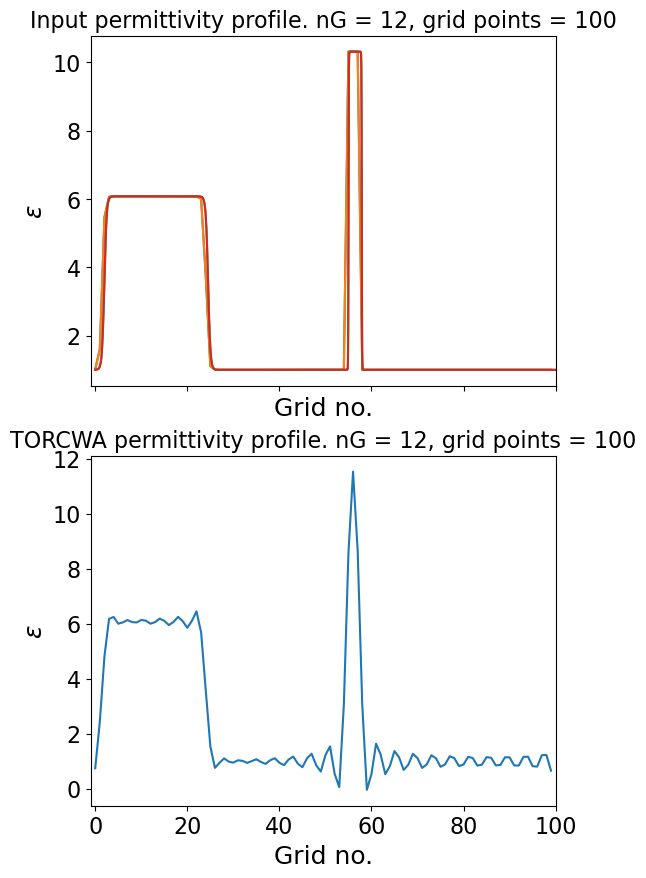

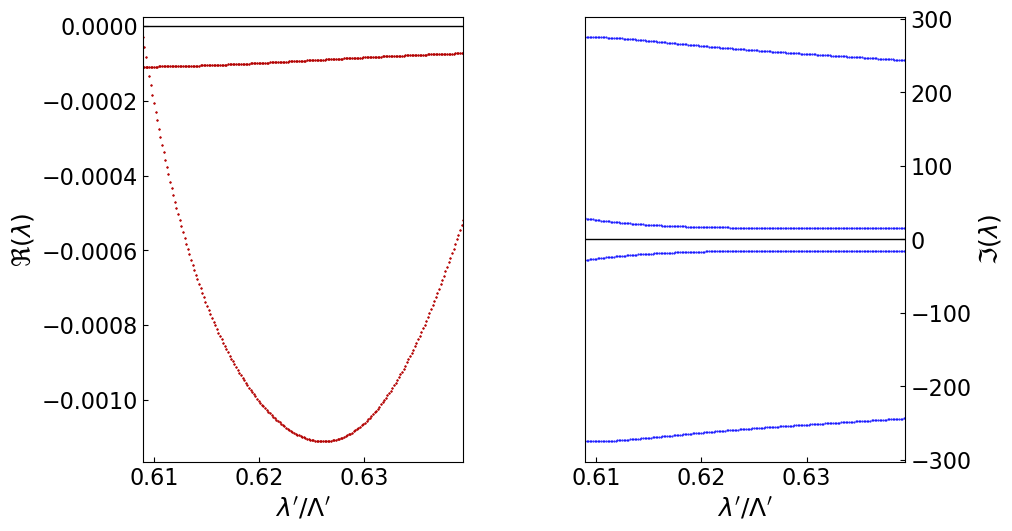

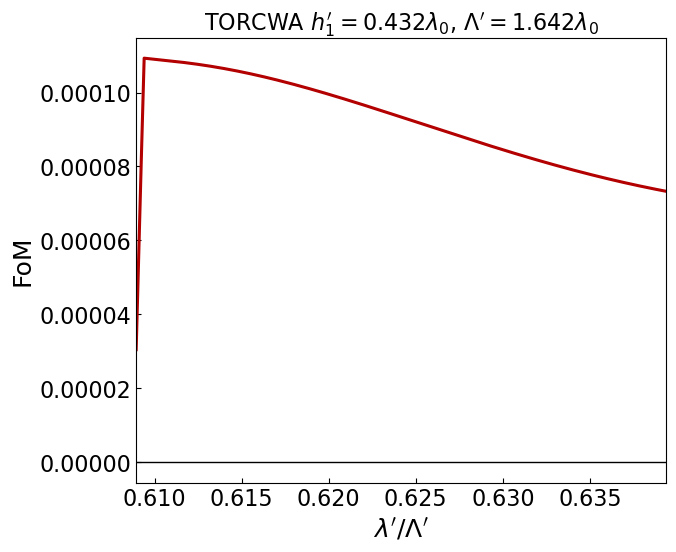

In [7]:
angle = 0.
n_plot = 200

# _, _, p_fig, p_ax = grating.show_permittivity(show_analytic_box=True, show_box_edges=False)
_, _, p_fig, p_ax = grating.show_permittivity(show_analytic_box=True)
eig_fig, eig_ax = grating.show_Eigs(wavelength_range, I0, n_plot, False, False, 'o')
spec_fig, spec_ax = grating.show_FOM_spectrum(angle=angle, wavelength_range=wavelength_range, num_plot_points=n_plot, I=I0)

save_fname = fname_preamble / f"opt{optimum_number}"
save_fname.mkdir(parents=True, exist_ok=True)
p_fig.savefig(save_fname / f"opt{optimum_number}_permittivity.pdf", bbox_inches = "tight")
eig_fig.savefig(save_fname / f"opt{optimum_number}_eigvals.pdf", bbox_inches = "tight")
spec_fig.savefig(save_fname / f"opt{optimum_number}_F_lam_spectrum.pdf", bbox_inches = "tight")

### Diffraction cutoffs

In [10]:
def ang(m, wavelength, pitch, positive_cutoff=True):
    if positive_cutoff:
        return np.arcsin(1 - m*wavelength/pitch)*(180/np.pi)
    else:
        return np.arcsin(-1 - m*wavelength/pitch)*(180/np.pi)

D = D1_ND([final_speed/100,0])
p = grating.to_numpy(grating.grating_pitch)

print("Minimum:")
print("v = 0")
print("+1 cutoff: ", ang(1, 1., p))
print("+2 order cutoff: ", ang(2, 1., p))
print("-1 cutoff: ", ang(-1, 1., p, False))
print("-2 order cutoff: ", ang(-2, 1., p, False))
print(f"v = {final_speed}%c")
print("+1 cutoff: ", ang(1, 1/D, p) )
print("+2 cutoff: ", ang(2, 1/D, p))
print("-1 cutoff: ", ang(-1, 1/D, p, False))
print("-2 order cutoff: ", ang(-2, 1/D, p, False))

Minimum:
v = 0
+1 cutoff:  0.866763632577216
+2 order cutoff:  -75.87025106964536
-1 cutoff:  -0.866763632577216
-2 order cutoff:  75.87025106964536
v = 20.0%c
+1 cutoff:  -11.900796348409385
+2 cutoff:  nan
-1 cutoff:  11.900796348409385
-2 order cutoff:  nan


/tmp/ipykernel_22349/3111625887.py:3: RuntimeWarning: invalid value encountered in arcsin
  return np.arcsin(1 - m*wavelength/pitch)*(180/np.pi)
/tmp/ipykernel_22349/3111625887.py:5: RuntimeWarning: invalid value encountered in arcsin
  return np.arcsin(-1 - m*wavelength/pitch)*(180/np.pi)


## Reflection spectra

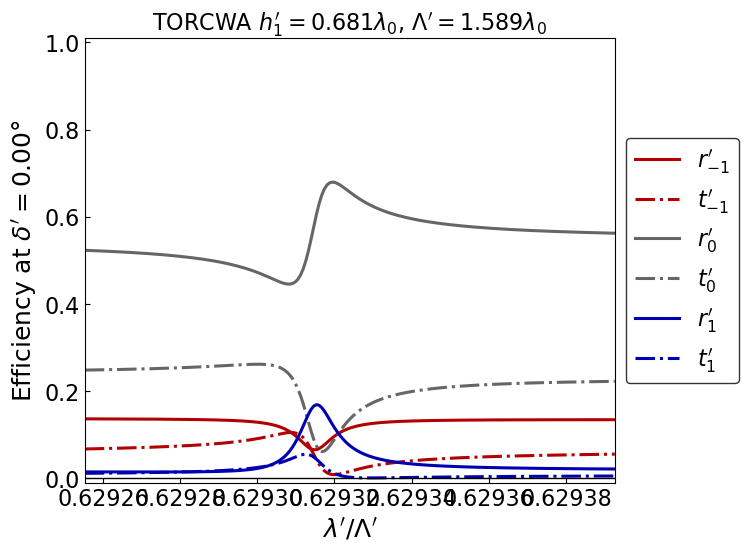

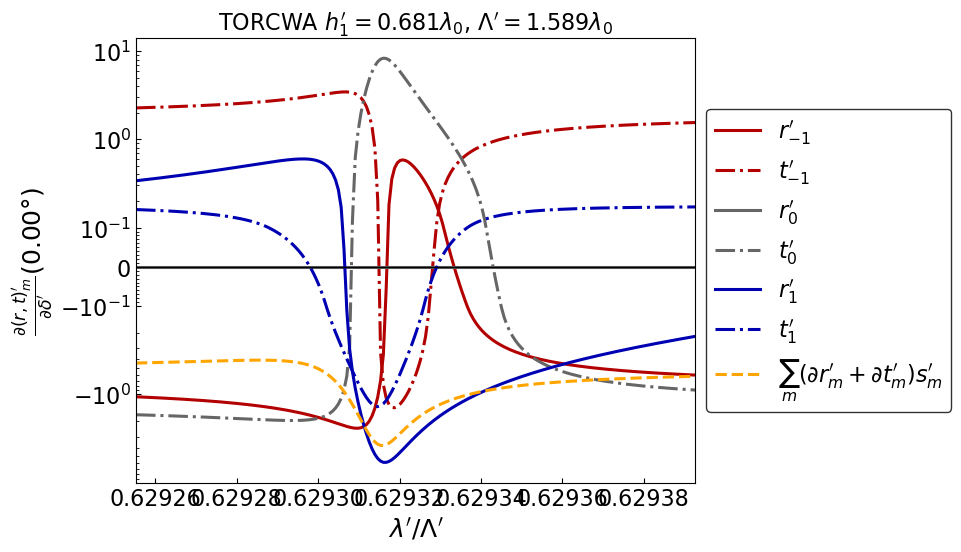

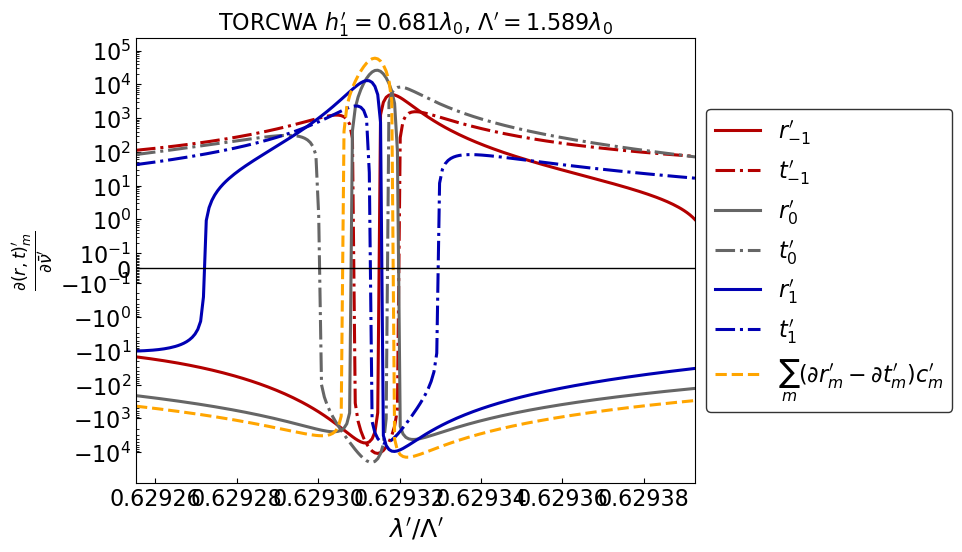

In [20]:
quantity = "rt"
n_plot = 200
r_fig, r_ax = grating.show_spectrum(0., quantity, wavelength_range=wavelength_range, num_plot_points=n_plot)
PDangle_fig, PDangle_ax = grating.show_spectrum(0., "PD"+quantity, wavelength_range=wavelength_range, num_plot_points=n_plot)
PDwavelength_fig, PDwavelength_ax = grating.show_spectrum(0., "PD"+quantity+"lam", wavelength_range=wavelength_range, 
                                                          num_plot_points=n_plot, show_freq_grad=True)
# rangle_fig, rangle_ax = grating.show_angular_efficiency(theta_max=20., num_plot_points=100)


In [25]:
PDangle_ax.set_yscale("linear")
PDangle_ax.set_ylim(-10.,10.)
PDwavelength_ax.set_yscale("linear")
PDwavelength_ax.set_ylim(-3e4,7.5e4)

save_fname = fname_preamble / f"opt{optimum_number}"
save_fname.mkdir(parents=True, exist_ok=True)
save_fname = str(save_fname)
ftype = ".pdf"
r_fig.savefig(save_fname + f"/opt{optimum_number}_" + quantity + ftype, bbox_inches="tight")
PDangle_fig.savefig(save_fname + f"/opt{optimum_number}_PD" + quantity + ftype, bbox_inches="tight")
PDwavelength_fig.savefig(save_fname + f"/opt{optimum_number}_PD" + quantity + "wavelength" + ftype, bbox_inches="tight")
# rangle_fig.savefig(save_fname + f"/opt{optimum_number}_rangle" + ftype, bbox_inches="tight")